In [2]:
# Regresión lineal simple en Python (con 1 variable)
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
%matplotlib inline 
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib import cm 
plt.rcParams['figure.figsize'] = (16, 9) 
plt.style.use('ggplot') 
from sklearn import linear_model 
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv("./wbes_sintetico.csv")

In [4]:
data.shape

(1200, 11)

In [5]:
data.head()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1


In [6]:
data.describe()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,sales_annual_usd,labor_productivity_usd_per_employee,successful
count,1190.000000,1174.000000,1167.000000,1165.000000,1200.000000,1200.000000,1173.000000,1200.000000,1200.000000
mean,12.194958,9.293867,0.420737,0.358798,0.181667,0.581667,29643.652245,2969.944112,0.422500
std,8.141142,5.591799,0.493889,0.479854,0.385730,0.493491,17012.208085,1880.785344,0.494163
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4616.266871,504.745429,0.000000
25%,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,17887.210677,1690.013365,0.000000
50%,10.000000,9.000000,0.000000,0.000000,0.000000,1.000000,25968.178330,2551.736302,0.000000
75%,15.000000,13.000000,1.000000,1.000000,0.000000,1.000000,37172.208984,3730.304934,1.000000
max,101.000000,28.000000,1.000000,1.000000,1.000000,1.000000,140346.603022,18925.813091,1.000000


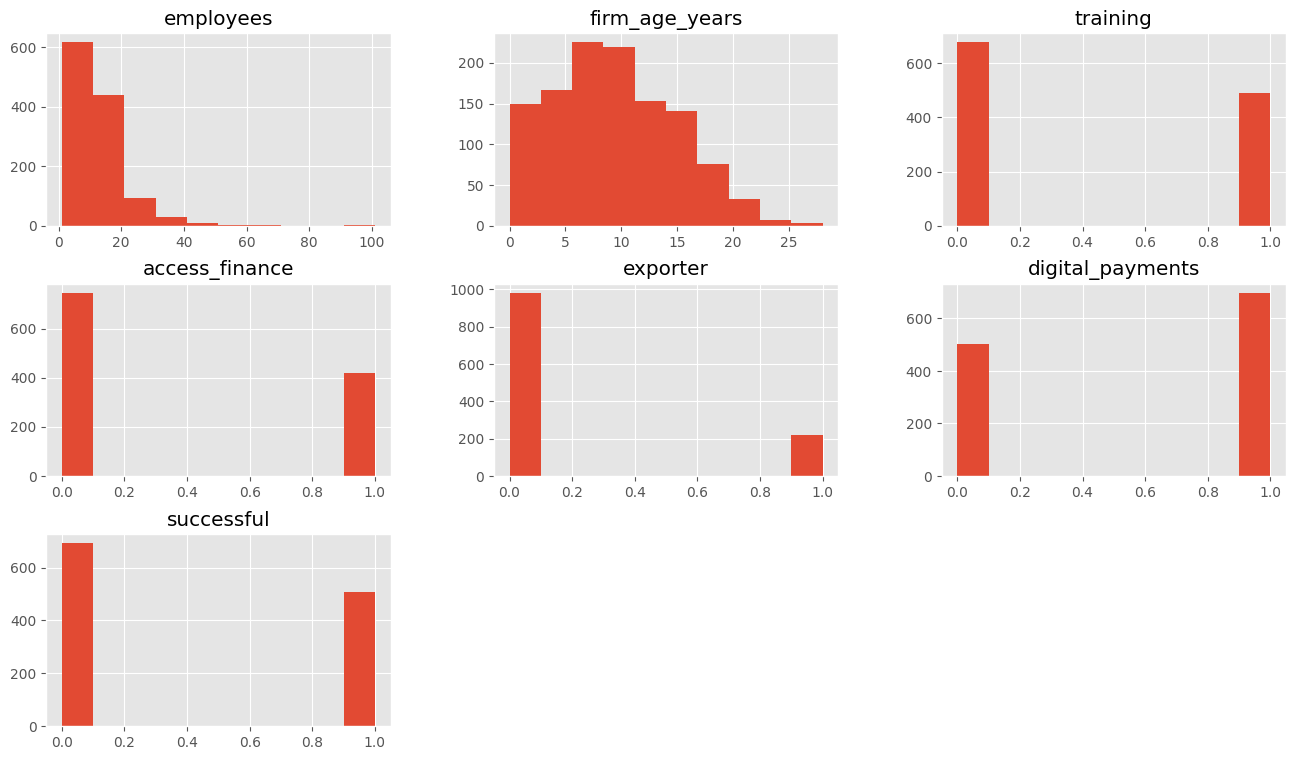

In [162]:
data.drop(['sales_annual_usd','labor_productivity_usd_per_employee'],axis=1).hist() 
plt.show()

In [167]:
filtered_data = data[(data['labor_productivity_usd_per_employee'] <= 2969.94) & (data['sales_annual_usd'] <= 29643.65)] 

f1 = filtered_data['labor_productivity_usd_per_employee'].values
f2 = filtered_data['sales_annual_usd'].values


In [168]:
filtered_data.describe()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,sales_annual_usd,labor_productivity_usd_per_employee,successful
count,490.000000,482.000000,479.000000,480.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,11.075510,8.091286,0.317328,0.254167,0.113131,0.525253,18691.253235,1822.078831,0.361616
std,5.495528,5.584725,0.465923,0.435846,0.317074,0.499867,5689.237335,640.210332,0.480954
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4616.266871,504.745429,0.000000
25%,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,14575.759947,1312.225732,0.000000
50%,10.000000,8.000000,0.000000,0.000000,0.000000,1.000000,18528.173071,1838.387435,0.000000
75%,13.000000,12.000000,1.000000,1.000000,0.000000,1.000000,23206.483332,2344.666901,1.000000
max,39.000000,28.000000,1.000000,1.000000,1.000000,1.000000,29554.676322,2966.333826,1.000000


In [169]:
dataX =filtered_data[["labor_productivity_usd_per_employee"]] 
X_train = np.array(dataX) 
y_train = filtered_data['sales_annual_usd'].values

# Creamos el objeto de Regresión Linear 
regr = linear_model.LinearRegression() 
 
# Entrenamiento del modelo 
regr.fit(X_train, y_train) 
 
y_pred = regr.predict(X_train) 

print('Independent term: \n', regr.intercept_) 
print("Mean squared error: %.2f" % mean_squared_error(y_train, y_pred)) 
print('Variance score: %.2f' % r2_score(y_train, y_pred))

Independent term: 
 16888.359692338763
Mean squared error: 31901560.00
Variance score: 0.01


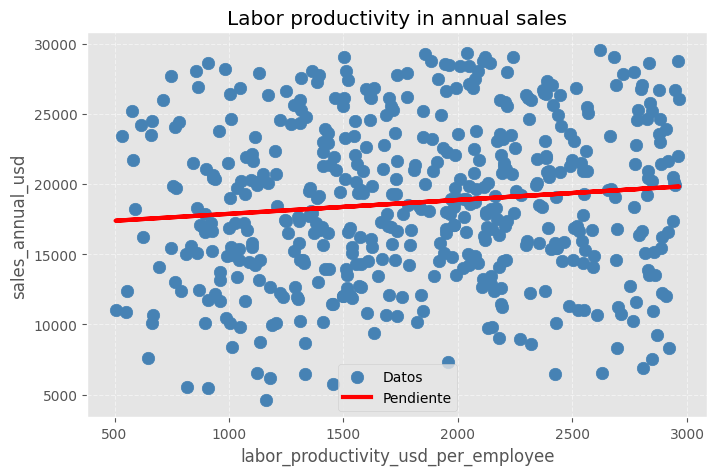

In [171]:
# Realizar la grafica de dispersión y la pendiente
x = X_train.ravel() 
plt.figure(figsize=(8, 5))
plt.scatter(x, y_train, color = 'steelblue', s = 80, label = 'Datos')
plt.plot(x, y_pred, color = 'red', linewidth = 3, label = 'Pendiente')
plt.xlabel('labor_productivity_usd_per_employee')
plt.ylabel('sales_annual_usd')
plt.title('Labor productivity in annual sales')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()